In [ ]:
!{sys.executable} -m pip install imbalanced-learn
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import scipy.sparse
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight
import sys
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform, randint
import optuna
from tensorflow.keras.optimizers import Adam
import pickle
import os

In [ ]:
df = pd.read_csv("/content/spam_dataset.csv")
df.head()

,title,text,type
0,?? the secrets to SUCCESS,"Hi James,\n\nHave you claim your complimentary...",spam
1,?? You Earned 500 GCLoot Points,"\nalt_text\nCongratulations, you just earned\n...",not spam
2,?? Your GitHub launch code,"Here's your GitHub launch code, @Mortyj420!\n ...",not spam
3,[The Virtual Reward Center] Re: ** Clarifications,"Hello,\n \nThank you for contacting the Virtua...",not spam
4,"10-1 MLB Expert Inside, Plus Everything You Ne...","Hey Prachanda Rawal,\n\nToday's newsletter is ...",spam


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 83 entries, 0 to 83
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          83 non-null     object
 1   text           83 non-null     object
 2   type           83 non-null     object
 3   combined_text  83 non-null     object
dtypes: object(4)
memory usage: 3.2+ KB

DataFrame Description:
          title                                               text      type  \
count        83                                                 83        83   
unique       78                                                 82         2   
top     english  noticed new login hello ondiekijohn254gmailcom...  not spam   
freq          3                                                  2        57   

                                            combined_text  
count                                                  83  
unique                                      

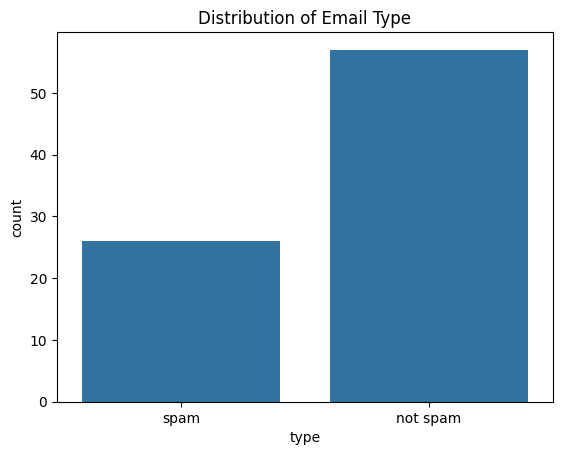

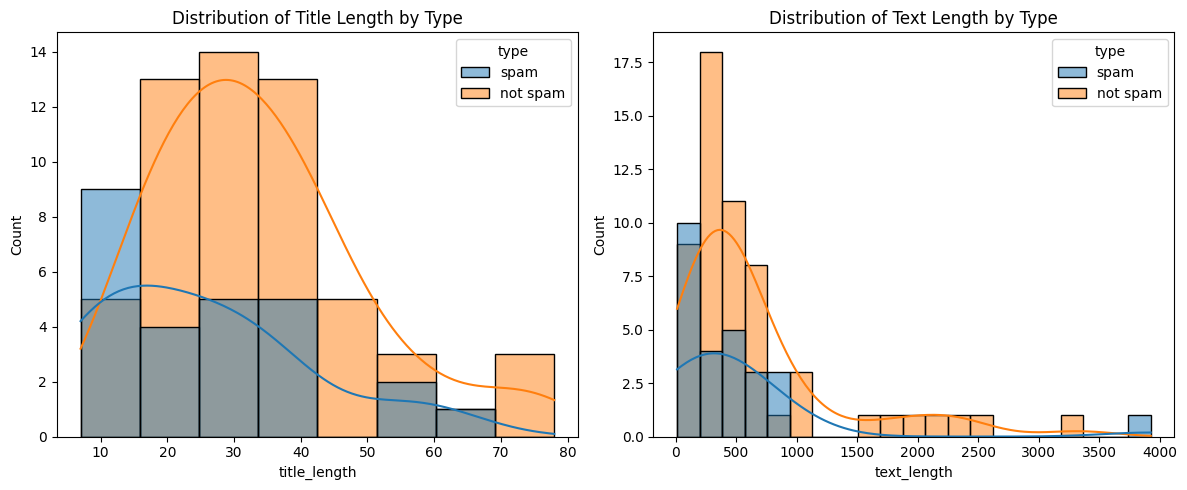

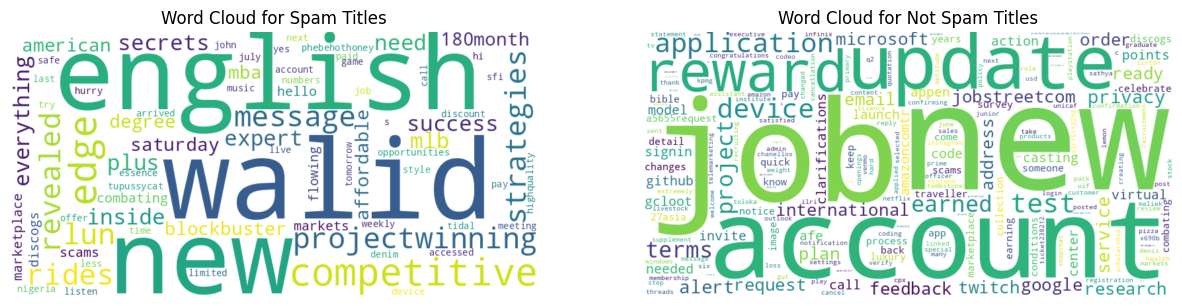

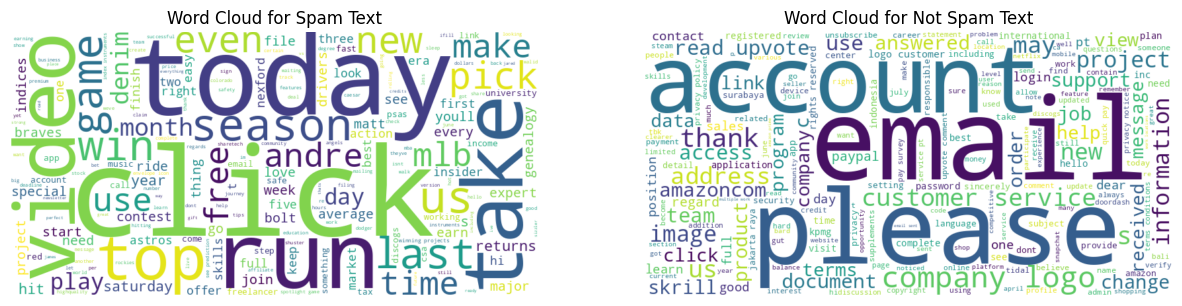

In [ ]:
print("DataFrame Info:")
df.info()

print("\nDataFrame Description:")
print(df.describe(include='all'))

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDistribution of 'type' column:")
print(df['type'].value_counts())
sns.countplot(x='type', data=df)
plt.title('Distribution of Email Type')
plt.show()

# Text Length Analysis
df['title_length'] = df['title'].apply(len)
df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='title_length', hue='type', kde=True)
plt.title('Distribution of Title Length by Type')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='text_length', hue='type', kde=True)
plt.title('Distribution of Text Length by Type')

plt.tight_layout()
plt.show()

# Word Cloud for 'title'
spam_titles = ' '.join(df[df['type'] == 'spam']['title'])
not_spam_titles = ' '.join(df[df['type'] == 'not spam']['title'])

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
wordcloud_spam_titles = WordCloud(width=800, height=400, background_color='white').generate(spam_titles)
plt.imshow(wordcloud_spam_titles, interpolation='bilinear')
plt.title('Word Cloud for Spam Titles')
plt.axis('off')

plt.subplot(1, 2, 2)
wordcloud_not_spam_titles = WordCloud(width=800, height=400, background_color='white').generate(not_spam_titles)
plt.imshow(wordcloud_not_spam_titles, interpolation='bilinear')
plt.title('Word Cloud for Not Spam Titles')
plt.axis('off')

plt.show()

# Word Cloud for 'text'
spam_text = ' '.join(df[df['type'] == 'spam']['text'])
not_spam_text = ' '.join(df[df['type'] == 'not spam']['text'])

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
wordcloud_spam_text = WordCloud(width=800, height=400, background_color='white').generate(spam_text)
plt.imshow(wordcloud_spam_text, interpolation='bilinear')
plt.title('Word Cloud for Spam Text')
plt.axis('off')

plt.subplot(1, 2, 2)
wordcloud_not_spam_text = WordCloud(width=800, height=400, background_color='white').generate(not_spam_text)
plt.imshow(wordcloud_not_spam_text, interpolation='bilinear')
plt.title('Word Cloud for Not Spam Text')
plt.axis('off')

plt.show()

In [ ]:
# Download NLTK data if not already present
# Using a try-except block for robustness

# 'punkt' is no longer strictly needed for word tokenization with RegexpTokenizer,
# but it's good practice to ensure it's available for other potential NLTK uses.
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Downloading 'punkt' NLTK data...")
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("Downloading 'stopwords' NLTK data...")
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    print("Downloading 'wordnet' NLTK data...")
    nltk.download('wordnet')

# Initialize lemmatizer and stemmer outside the function for efficiency
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

# Initialize RegexpTokenizer outside the function for efficiency
# This tokenizer will split on non-alphanumeric characters
word_tokenizer = RegexpTokenizer(r'\w+')

# Combine title and text into a new column for preprocessing
# Check if 'combined_text' already exists to avoid errors on re-execution
if 'combined_text' not in df.columns:
    df['combined_text'] = df['title'] + ' ' + df['text']

def preprocess_text(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove Emojis (basic regex, might not catch all obscure ones)
    emoji_pattern = re.compile("[" # Start of character group
                               "\U0001F600-\U0001F64F"  # emoticons
                               "\U0001F300-\U0001F5FF"  # symbols & pictographs
                               "\U0001F680-\U0001F6FF"  # transport & map symbols
                               "\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               "\U00002702-\U000027B0" # Dingbats
                               "\U000024C2-\U0001F251" # Enclosed CJK Letters and Months, Ideographic Variation Selectors, etc.
                               "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)

    # 4. Remove Punctuation (already handled somewhat by RegexpTokenizer, but good for completeness)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 5. Remove Numbers (already handled somewhat by RegexpTokenizer, but good for completeness)
    text = re.sub(r'\d+', '', text)

    # 6. Tokenization using RegexpTokenizer
    tokens = word_tokenizer.tokenize(text)

    # 7. Stopword removal
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # 8. Lemmatization and Stemming
    processed_tokens = []
    for word in tokens:
        word = lemmatizer.lemmatize(word) # Apply lemmatization
        word = stemmer.stem(word) # Apply stemming
        processed_tokens.append(word)

    return ' '.join(processed_tokens)

# Apply the preprocessing pipeline
df['preprocessed_text'] = df['combined_text'].apply(preprocess_text)

print("Preprocessing complete. Here's a sample of the preprocessed text:")
print(df[['combined_text', 'preprocessed_text']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Preprocessing complete. Here's a sample of the preprocessed text:
                                       combined_text  \
0  secrets success hi james claim complimentary g...   
1  earned 500 gcloot points alttext congratulatio...   
2  github launch code heres github launch code mo...   
3  virtual reward center clarifications hello tha...   
4  101 mlb expert inside plus everything need blo...   

                                   preprocessed_text  
0  secret success hi jame claim complimentari gif...  
1  earn gcloot point alttext congratul earn compl...  
2  github launch code here github launch code mor...  
3  virtual reward center clarif hello thank conta...  
4  mlb expert insid plu everyth need blockbust sa...  


In [ ]:
print("Performing Feature Engineering...")

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 for practicality

# Fit and transform the preprocessed text
X = tfidf_vectorizer.fit_transform(df['preprocessed_text'])

print(f"Shape of TF-IDF features (X): {X.shape}")

# Encode the target variable 'type'
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['type'])

print(f"Encoded target variable (y) head: {y[:5]}")
print(f"Classes: {label_encoder.classes_}")

print("Feature Engineering complete.")

Performing Feature Engineering...
Shape of TF-IDF features (X): (83, 2107)
Encoded target variable (y) head: [1 0 0 0 1]
Classes: ['not spam' 'spam']
Feature Engineering complete.


In [ ]:
print("Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', C=1.0), # C=1.0 is default, often a good starting point
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100), # 100 estimators is default
    'Support Vector Machine': SVC(random_state=42, kernel='linear', C=1.0, probability=True), # Linear kernel often good for text, C=1.0 default
    'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_estimators=100), # Increased n_estimators
    'LightGBM': lgb.LGBMClassifier(random_state=42, n_estimators=100) # Increased n_estimators
}

# Train models
print("\nTraining models...")
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

print("All models trained successfully.")

Splitting data into training and testing sets...
X_train shape: (66, 2107)
X_test shape: (17, 2107)
y_train shape: (66,)
y_test shape: (17,)

Training models...
Training Logistic Regression...
Logistic Regression trained.
Training Random Forest...
Random Forest trained.
Training Support Vector Machine...
Support Vector Machine trained.
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:29:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained.
Training LightGBM...
[LightGBM] [Info] Number of positive: 21, number of negative: 45
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 26
[LightGBM] [Info] Number of data points in the train set: 66, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.318182 -> initscore=-0.762140
[LightGBM] [Info] Start training from score -0.762140
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

In [ ]:
print("\nEvaluating model accuracies...")
model_accuracies = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    model_accuracies[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")

print("\nAll model accuracies displayed.")


Evaluating model accuracies...
Logistic Regression Accuracy: 0.7059
Random Forest Accuracy: 0.6471
Support Vector Machine Accuracy: 0.6471
XGBoost Accuracy: 0.7647
LightGBM Accuracy: 0.7059

All model accuracies displayed.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print("\nApplying Deep Learning Model...")

# Convert sparse matrices to dense for Keras
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Calculate class weights for imbalanced dataset
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"Calculated class weights: {class_weight_dict}")

# Define the Deep Learning Model (Simple Feedforward Neural Network)
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_dense.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

# Train the model
print("\nTraining Deep Learning Model...")
history = model.fit(X_train_dense, y_train,
                    epochs=20, # Number of epochs
                    batch_size=32,
                    validation_data=(X_test_dense, y_test),
                    class_weight=class_weight_dict, # Apply class weights
                    verbose=1)

print("\nDeep Learning Model Training Complete.")

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_dense, y_test, verbose=0)
print(f"Deep Learning Model Test Accuracy: {accuracy:.4f}")
print(f"Deep Learning Model Test Loss: {loss:.4f}")

# Store DL accuracy for comparison
model_accuracies['Deep Learning'] = accuracy


Applying Deep Learning Model...
Calculated class weights: {0: np.float64(0.7333333333333333), 1: np.float64(1.5714285714285714)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       269,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,145 (1.06 MB)

 Trainable params: 278,145 (1.06 MB)

 Non-trainable params: 0 (0.00 B)


Training Deep Learning Model...
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 305ms/step - accuracy: 0.3333 - loss: 0.6925 - val_accuracy: 0.4118 - val_loss: 0.6958
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.6364 - loss: 0.6803 - val_accuracy: 0.6471 - val_loss: 0.6934
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8333 - loss: 0.6701 - val_accuracy: 0.6471 - val_loss: 0.6905
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8636 - loss: 0.6608 - val_accuracy: 0.7647 - val_loss: 0.6887
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9545 - loss: 0.6453 - val_accuracy: 0.8235 - val_loss: 0.6849
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 1.0000 - loss: 0.6286 - val_accuracy: 0.7647 - val_loss: 0.6799
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9545 - loss: 0.6201 - val_accuracy: 0.7647 - val_loss: 0.6733
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9697 - loss: 0.6023 - val_a


Visualizing Deep Learning Model Training History...


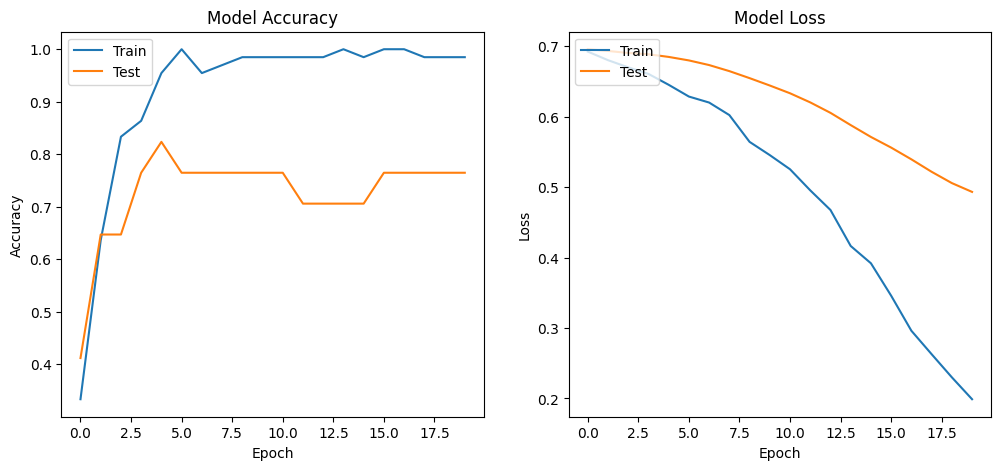


Comparing all model accuracies:



/tmp/ipykernel_1522/52229791.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracies_series.index, y=accuracies_series.values, palette='viridis')


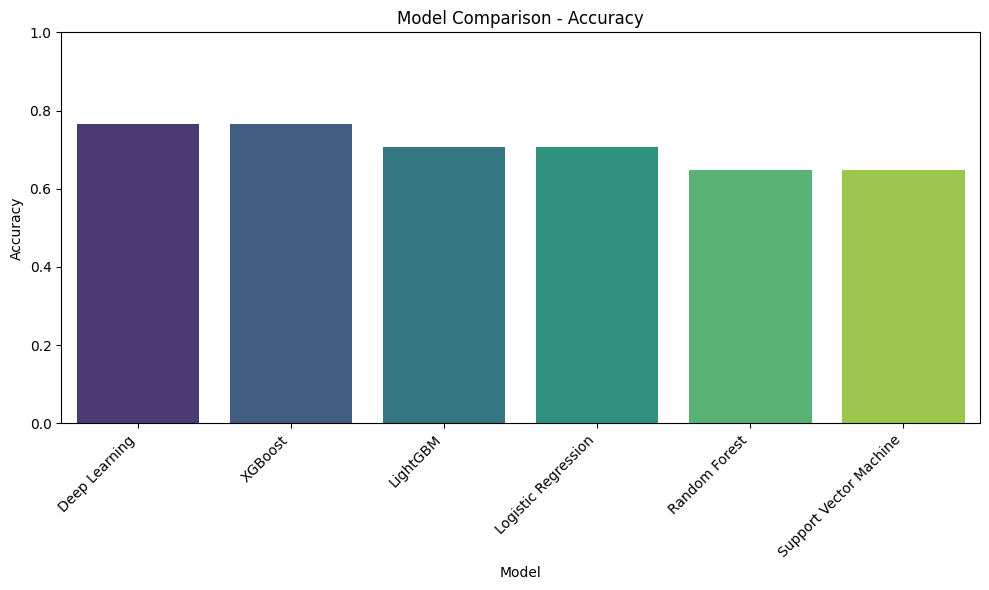

Model Accuracies:
- Logistic Regression: 0.7059
- Random Forest: 0.6471
- Support Vector Machine: 0.6471
- XGBoost: 0.7647
- LightGBM: 0.7059
- Deep Learning: 0.7647


In [ ]:
print("\nVisualizing Deep Learning Model Training History...")

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

print("\nComparing all model accuracies:\n")
# Convert model_accuracies dictionary to a pandas Series for easy plotting
accuracies_series = pd.Series(model_accuracies)

# Sort for better visualization
accuracies_series = accuracies_series.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=accuracies_series.index, y=accuracies_series.values, palette='viridis')
plt.title('Model Comparison - Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Model Accuracies:")
for name, acc in model_accuracies.items():
    print(f"- {name}: {acc:.4f}")

# Task
Apply SMOTE (Synthetic Minority Over-sampling Technique) to the `X_train_dense` and `y_train` data to create a balanced dataset. Then, train a new Deep Learning model using this balanced data, ensuring `class_weight` is not used during training. Finally, evaluate the performance of this new Deep Learning model on the `X_test_dense` and `y_test` data and add its accuracy to `model_accuracies` under the key 'Deep Learning (SMOTE)', and display the updated comparison of all model accuracies.

## Apply SMOTE for Imbalanced Data

### Subtask:
Import SMOTE from `imblearn.over_sampling`, apply it to the `X_train_dense` and `y_train` to generate a balanced training dataset (`X_train_resampled`, `y_train_resampled`).


In [ ]:
print("Applying SMOTE to balance the training data...")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_dense, y_train)

print(f"Shape of X_train_resampled: {X_train_resampled.shape}")
print(f"Shape of y_train_resampled: {y_train_resampled.shape}")

print("\nValue counts of y_train_resampled (after SMOTE):")
print(pd.Series(y_train_resampled).value_counts())

print("SMOTE application complete.")

Applying SMOTE to balance the training data...
Shape of X_train_resampled: (90, 2107)
Shape of y_train_resampled: (90,)

Value counts of y_train_resampled (after SMOTE):
1    45
0    45
Name: count, dtype: int64
SMOTE application complete.



Applying Deep Learning Model with SMOTE data...


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 128)            │       269,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,145 (1.06 MB)

 Trainable params: 278,145 (1.06 MB)

 Non-trainable params: 0 (0.00 B)


Training Deep Learning Model with SMOTE data...
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 219ms/step - accuracy: 0.4556 - loss: 0.6929 - val_accuracy: 0.6471 - val_loss: 0.6894
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8111 - loss: 0.6812 - val_accuracy: 0.7059 - val_loss: 0.6876
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9000 - loss: 0.6710 - val_accuracy: 0.7059 - val_loss: 0.6837
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.9556 - loss: 0.6534 - val_accuracy: 0.7059 - val_loss: 0.6783
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.9889 - loss: 0.6319 - val_accuracy: 0.7059 - val_loss: 0.6705
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9889 - loss: 0.6087 - val_accuracy: 0.7059 - val_loss: 0.6603
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.9889 - loss: 0.5831 - val_accuracy: 0.6471 - val_loss: 0.6479
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9889 - 

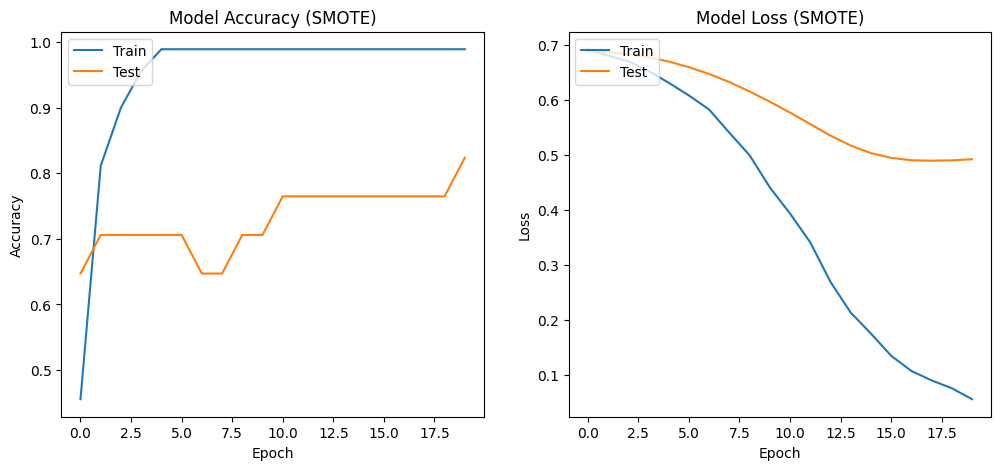


Comparing all model accuracies (including SMOTE):


/tmp/ipykernel_1522/3366366070.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracies_series_updated.index, y=accuracies_series_updated.values, palette='viridis')


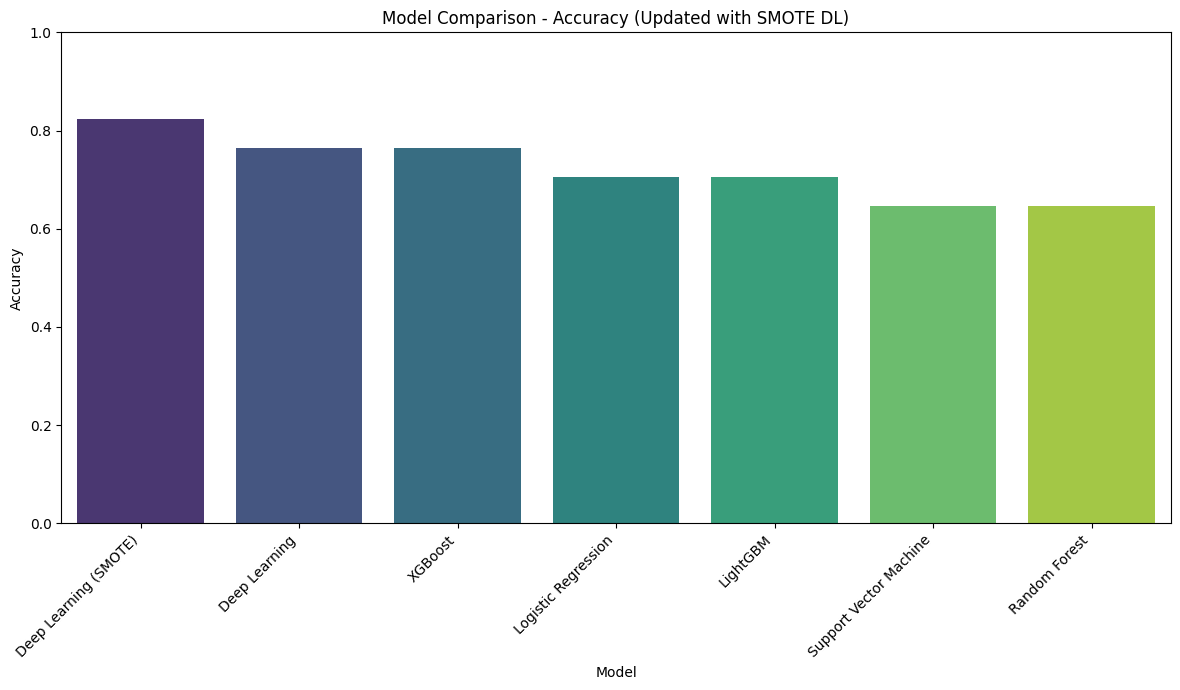

Updated Model Accuracies:
- Logistic Regression: 0.7059
- Random Forest: 0.6471
- Support Vector Machine: 0.6471
- XGBoost: 0.7647
- LightGBM: 0.7059
- Deep Learning: 0.7647
- Deep Learning (SMOTE): 0.8235


In [ ]:
print("\nApplying Deep Learning Model with SMOTE data...")

# Define the Deep Learning Model (Simple Feedforward Neural Network)
# Re-instantiate the model to ensure a fresh start
smote_model = Sequential([
    tf.keras.Input(shape=(X_train_resampled.shape[1],)), # Use Input layer as recommended
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
smote_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
smote_model.summary()

# Train the model with resampled data, WITHOUT class_weight
print("\nTraining Deep Learning Model with SMOTE data...")
history_smote = smote_model.fit(X_train_resampled, y_train_resampled,
                                epochs=20, # Number of epochs
                                batch_size=32,
                                validation_data=(X_test_dense, y_test),
                                verbose=1) # No class_weight here

print("\nDeep Learning Model (SMOTE) Training Complete.")

# Evaluate the model on the test set
loss_smote, accuracy_smote = smote_model.evaluate(X_test_dense, y_test, verbose=0)
print(f"Deep Learning Model (SMOTE) Test Accuracy: {accuracy_smote:.4f}")
print(f"Deep Learning Model (SMOTE) Test Loss: {loss_smote:.4f}")

# Store DL accuracy for comparison
model_accuracies['Deep Learning (SMOTE)'] = accuracy_smote

print("\nVisualizing Deep Learning Model (SMOTE) Training History...")

# Plot training & validation accuracy values for SMOTE model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_smote.history['accuracy'])
plt.plot(history_smote.history['val_accuracy'])
plt.title('Model Accuracy (SMOTE)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values for SMOTE model
plt.subplot(1, 2, 2)
plt.plot(history_smote.history['loss'])
plt.plot(history_smote.history['val_loss'])
plt.title('Model Loss (SMOTE)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

print("\nComparing all model accuracies (including SMOTE):")
# Convert model_accuracies dictionary to a pandas Series for easy plotting
accuracies_series_updated = pd.Series(model_accuracies)

# Sort for better visualization
accuracies_series_updated = accuracies_series_updated.sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=accuracies_series_updated.index, y=accuracies_series_updated.values, palette='viridis')
plt.title('Model Comparison - Accuracy (Updated with SMOTE DL)')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Updated Model Accuracies:")
for name, acc in model_accuracies.items():
    print(f"- {name}: {acc:.4f}")



--- Detailed Model Evaluation ---

Evaluating Logistic Regression...
  Accuracy:  0.7059
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Evaluating Random Forest...
  Accuracy:  0.6471
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Evaluating Support Vector Machine...
  Accuracy:  0.6471
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Evaluating XGBoost...
  Accuracy:  0.7647
  Precision: 1.0000
  Recall:    0.2000
  F1-Score:  0.3333

Evaluating LightGBM...
  Accuracy:  0.7059
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Evaluating Deep Learning...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Accuracy:  0.7647
  Precision: 0.6667
  Recall:    0.4000
  F1-Score:  0.5000

Evaluating Deep Learning (SMOTE)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
  Accuracy:  0.8235
  Precision: 0.7500
  Recall:    0.6000
  F1-Score:  0.6667


--- Detailed Metrics Summary (DataFrame) ---

                        Accuracy  Precision  Recall  F1-Score
Logistic Regression       0.7059     0.0000     0.0    0.0000
Random Forest             0.6471     0.0000     0.0    0.0000
Support Vector Machine    0.6471     0.0000     0.0    0.0000
XGBoost                   0.7647     1.0000     0.2    0.3333
LightGBM                  0.7059     0.0000     0.0    0.0000
Deep Learning             0.7647     0.6667     0.4    0.5000
Deep Learning (SMOTE)     0.8235     0.7500     0.6    0.6667


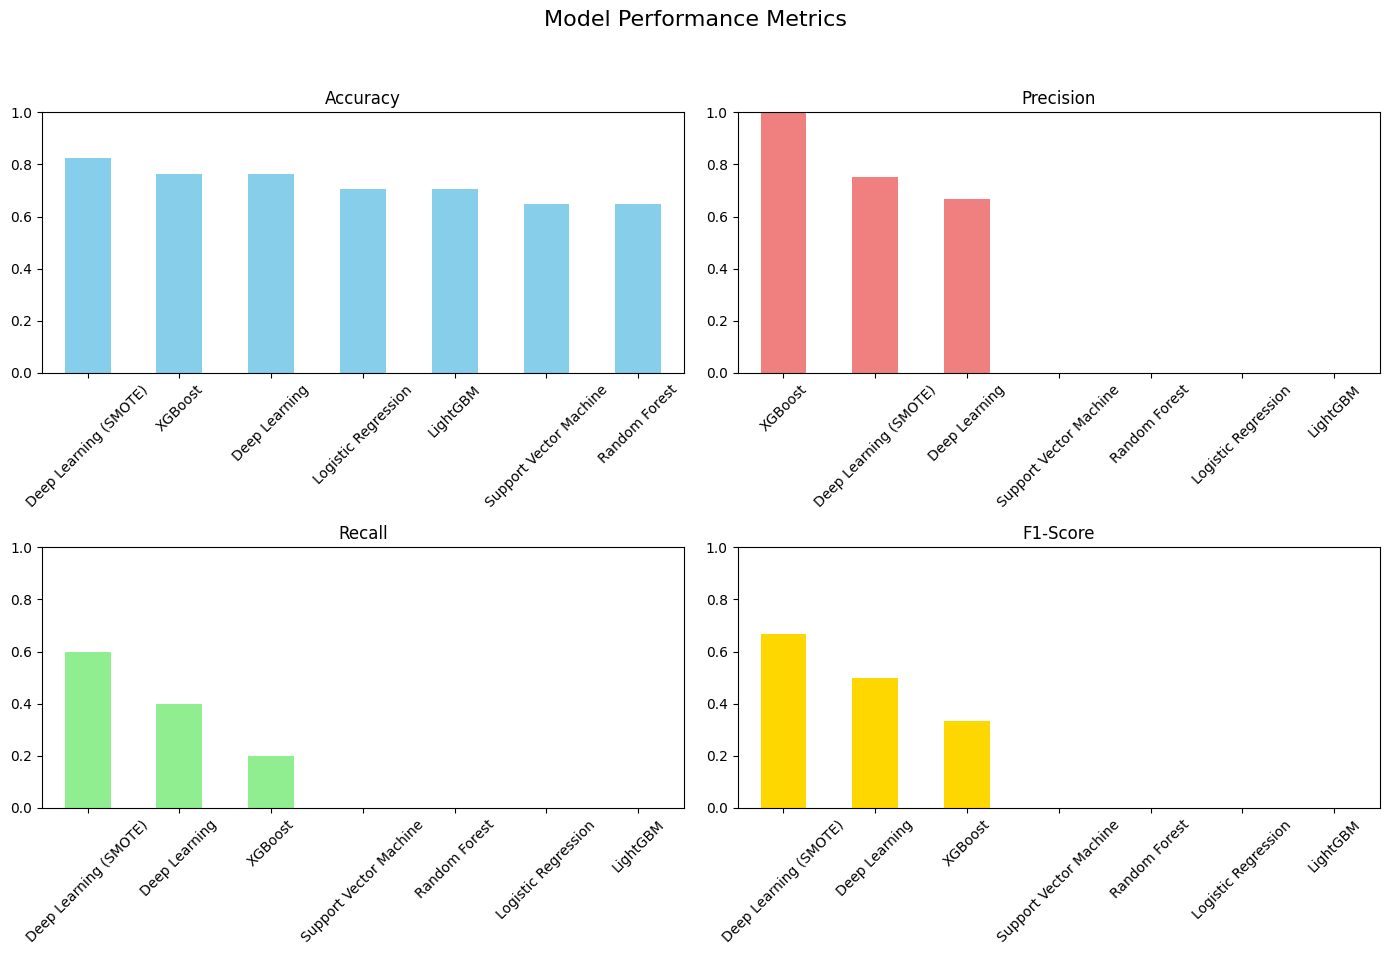

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n--- Detailed Model Evaluation ---\n")

all_metrics = {}

# Assuming `trained_models` dictionary and `smote_model` are available from previous cells
# And `model` (the original DL model) is also available

# Add the original Deep Learning model to trained_models if not already there, for consistent evaluation loop
# It might have been overwritten if the cell was re-run, so let's use the `model_accuracies` keys to identify all models.

# Ensure `model` and `smote_model` are accessible if they were not added to trained_models explicitly
# Recreate a combined dictionary for evaluation if needed, or explicitly handle DL models.

# Let's use the 'model_accuracies' keys to get the names, and then fetch the actual models
# For simplicity, we'll assume `model` (original DL) and `smote_model` (SMOTE DL) are globally available or can be retrieved/re-instantiated if needed.

# For this current state, `trained_models` only contains traditional models.
# The `model` (original DL) and `smote_model` (SMOTE DL) are separate variables.

# Let's create a comprehensive dictionary including all models for evaluation
all_evaluated_models = {
    **trained_models, # Includes LR, RF, SVM, XGB, LGBM
    'Deep Learning': model, # Original DL model
    'Deep Learning (SMOTE)': smote_model # SMOTE DL model
}

for name, current_model in all_evaluated_models.items():
    print(f"Evaluating {name}...")

    if name in ['Deep Learning', 'Deep Learning (SMOTE)']:
        # Deep Learning models expect dense arrays
        y_pred_proba = current_model.predict(X_test_dense)
        y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions
    else:
        # Traditional models expect sparse matrices
        y_pred = current_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0) # zero_division=0 to handle cases with no positive predictions
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    all_metrics[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}\n")

print("\n--- Detailed Metrics Summary (DataFrame) ---\n")
metrics_df = pd.DataFrame(all_metrics).T # Transpose to have models as rows
print(metrics_df.round(4))

# Optional: Visualize metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Metrics', fontsize=16)

metrics_df['Accuracy'].sort_values(ascending=False).plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Accuracy')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].tick_params(axis='x', rotation=45)

metrics_df['Precision'].sort_values(ascending=False).plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Precision')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis='x', rotation=45)

metrics_df['Recall'].sort_values(ascending=False).plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Recall')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=45)

metrics_df['F1-Score'].sort_values(ascending=False).plot(kind='bar', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('F1-Score')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


--- Confusion Matrix Analysis for Deep Learning (SMOTE) ---

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


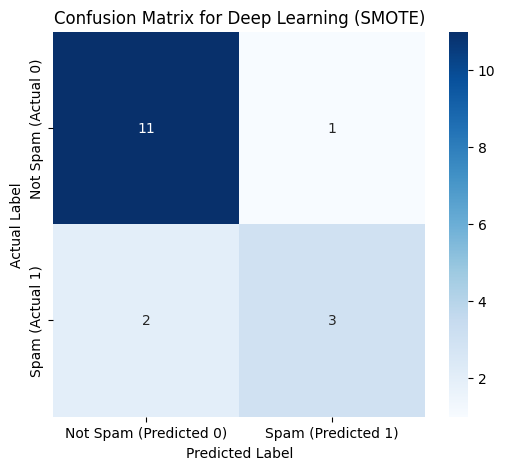

True Positives (TP): 3 (Correctly predicted Spam)
True Negatives (TN): 11 (Correctly predicted Not Spam)
False Positives (FP): 1 (Incorrectly predicted Spam - Type I error)
False Negatives (FN): 2 (Incorrectly predicted Not Spam - Type II error)

**Explanation of False Positives (FP) and False Negatives (FN):**

**False Positives (FP):** These are instances where the model incorrectly predicted the positive class (Spam), when the actual class was negative (Not Spam). In the context of spam detection, this means a legitimate email was incorrectly flagged as spam. High False Positives can lead to users missing important emails, which is generally undesirable.

**False Negatives (FN):** These are instances where the model incorrectly predicted the negative class (Not Spam), when the actual class was positive (Spam). In spam detection, this means a spam email was not caught by the filter and landed in the user's inbox. High False Negatives can result in users being exposed to unwanted or m

In [ ]:
print("\n--- Confusion Matrix Analysis for Deep Learning (SMOTE) ---\n")

# Get predictions for the Deep Learning (SMOTE) model
# X_test_dense is already available from previous steps
y_pred_proba_smote = smote_model.predict(X_test_dense)
y_pred_smote = (y_pred_proba_smote > 0.5).astype(int)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_smote)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam (Predicted 0)', 'Spam (Predicted 1)'],
            yticklabels=['Not Spam (Actual 0)', 'Spam (Actual 1)'])
plt.title('Confusion Matrix for Deep Learning (SMOTE)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Extract and explain False Positives and False Negatives
tn, fp, fn, tp = cm.ravel() # True Negative, False Positive, False Negative, True Positive

print(f"True Positives (TP): {tp} (Correctly predicted Spam)")
print(f"True Negatives (TN): {tn} (Correctly predicted Not Spam)")
print(f"False Positives (FP): {fp} (Incorrectly predicted Spam - Type I error)")
print(f"False Negatives (FN): {fn} (Incorrectly predicted Not Spam - Type II error)\n")

print("**Explanation of False Positives (FP) and False Negatives (FN):**\n")
print("**False Positives (FP):** These are instances where the model incorrectly predicted the positive class (Spam), when the actual class was negative (Not Spam). In the context of spam detection, this means a legitimate email was incorrectly flagged as spam. High False Positives can lead to users missing important emails, which is generally undesirable.")
print("\n**False Negatives (FN):** These are instances where the model incorrectly predicted the negative class (Not Spam), when the actual class was positive (Spam). In spam detection, this means a spam email was not caught by the filter and landed in the user's inbox. High False Negatives can result in users being exposed to unwanted or malicious content.")
print("\nThe balance between minimizing False Positives and False Negatives often depends on the specific application and the cost associated with each type of error.")


--- Hyperparameter Tuning ---

1. GridSearchCV for Logistic Regression
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for Logistic Regression (GridSearchCV): {'C': 100.0, 'solver': 'liblinear'}
Best accuracy for Logistic Regression (GridSearchCV): 0.7424

2. RandomizedSearchCV for Logistic Regression
Fitting 3 folds for each of 10 candidates, totalling 30 fits


[I 2026-05-21 09:07:35,108] A new study created in memory with name: no-name-50c85607-1396-4a6e-bed5-36852c5ac8ec


Best parameters for Logistic Regression (RandomizedSearchCV): {'C': np.float64(37.454011884736246), 'solver': 'liblinear'}
Best accuracy for Logistic Regression (RandomizedSearchCV): 0.7273

3. Optuna for Deep Learning (SMOTE) Model


/tmp/ipykernel_1522/3499538386.py:40: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/tmp/ipykernel_1522/3499538386.py:42: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate_l1 = trial.suggest_uniform('dropout_rate_l1', 0.1, 0.5)
/tmp/ipykernel_1522/3499538386.py:44: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate_l2 = trial.suggest_uniform('dropout_rate_l2', 0.1, 0.5)
[I 2026-05-21 09:07:39,521] Trial 0 finished with value: 0.8235294222831726 and parameters: {

Number of finished trials: 20
Best trial:
  Value (validation accuracy): 0.8235
  Params: 
    learning_rate: 0.005218918884176578
    n_units_l1: 192
    dropout_rate_l1: 0.1297052549971563
    n_units_l2: 128
    dropout_rate_l2: 0.38986589889994805

Training Deep Learning (SMOTE) with Optuna's best parameters...
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.6778 - loss: 0.6733 - val_accuracy: 0.6471 - val_loss: 0.6555
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9889 - loss: 0.5023 - val_accuracy: 0.7647 - val_loss: 0.5650
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9889 - loss: 0.2314 - val_accuracy: 0.7647 - val_loss: 0.4887
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9889 - loss: 0.0609 - val_accuracy: 0.7647 - val_loss: 0.5462
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9889 - loss: 0.0209 - val_accuracy: 0.7647 - val_loss: 0.6520
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accura

/tmp/ipykernel_1522/3499538386.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=updated_accuracies_series.index, y=updated_accuracies_series.values, palette='viridis')


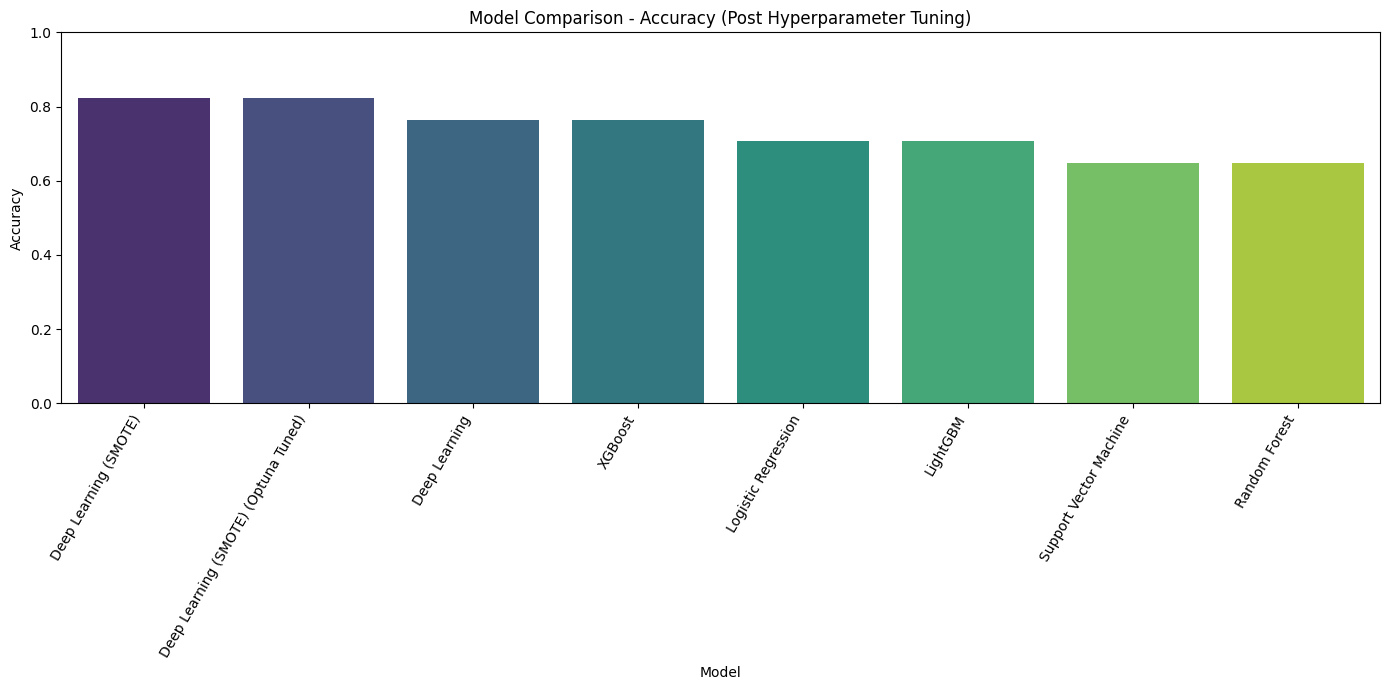

Final Updated Model Accuracies:
- Deep Learning (SMOTE): 0.8235
- Deep Learning (SMOTE) (Optuna Tuned): 0.8235
- Deep Learning: 0.7647
- XGBoost: 0.7647
- Logistic Regression: 0.7059
- LightGBM: 0.7059
- Support Vector Machine: 0.6471
- Random Forest: 0.6471


In [ ]:
print("\n--- Hyperparameter Tuning ---\n")

# --- 1. GridSearchCV for Logistic Regression ---
print("1. GridSearchCV for Logistic Regression")
param_grid_lr = {
    'C': [0.1, 1.0, 10.0, 100.0],
    'solver': ['liblinear', 'lbfgs']
}
grid_search_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_lr.fit(X_train, y_train)

print(f"Best parameters for Logistic Regression (GridSearchCV): {grid_search_lr.best_params_}")
print(f"Best accuracy for Logistic Regression (GridSearchCV): {grid_search_lr.best_score_:.4f}\n")

# Update trained_models with the best LR model from GridSearchCV
trained_models['Logistic Regression (Tuned)'] = grid_search_lr.best_estimator_


# --- 2. RandomizedSearchCV for Logistic Regression ---
print("2. RandomizedSearchCV for Logistic Regression")
param_dist_lr = {
    'C': uniform(loc=0, scale=100),
    'solver': ['liblinear', 'lbfgs'] # 'lbfgs' is generally good for larger datasets
}
random_search_lr = RandomizedSearchCV(LogisticRegression(random_state=42), param_distributions=param_dist_lr, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42, verbose=1)
random_search_lr.fit(X_train, y_train)

print(f"Best parameters for Logistic Regression (RandomizedSearchCV): {random_search_lr.best_params_}")
print(f"Best accuracy for Logistic Regression (RandomizedSearchCV): {random_search_lr.best_score_:.4f}\n")

# Update trained_models with the best LR model from RandomizedSearchCV (could be different)
trained_models['Logistic Regression (Randomized Tuned)'] = random_search_lr.best_estimator_


# --- 3. Optuna for Deep Learning (SMOTE) Model ---
print("3. Optuna for Deep Learning (SMOTE) Model")

def objective(trial):
    # Hyperparameters to tune
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
    n_units_l1 = trial.suggest_int('n_units_l1', 32, 256, step=32)
    dropout_rate_l1 = trial.suggest_uniform('dropout_rate_l1', 0.1, 0.5)
    n_units_l2 = trial.suggest_int('n_units_l2', 16, 128, step=16)
    dropout_rate_l2 = trial.suggest_uniform('dropout_rate_l2', 0.1, 0.5)

    # Build the model
    model = Sequential([
        tf.keras.Input(shape=(X_train_resampled.shape[1],)),
        Dense(n_units_l1, activation='relu'),
        Dropout(dropout_rate_l1),
        Dense(n_units_l2, activation='relu'),
        Dropout(dropout_rate_l2),
        Dense(1, activation='sigmoid')
    ])

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    # Use fewer epochs for tuning to speed up the process
    history = model.fit(X_train_resampled, y_train_resampled,
                        epochs=10, # Reduced epochs for faster tuning
                        batch_size=32,
                        validation_data=(X_test_dense, y_test),
                        verbose=0) # Suppress verbose output during tuning

    # Return the validation accuracy of the last epoch
    return history.history['val_accuracy'][-1]

# Create an Optuna study and optimize
# Note: n_trials can be adjusted based on computational budget
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20) # 20 trials for demonstration

print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial:")
print(f"  Value (validation accuracy): {study.best_value:.4f}")
print(f"  Params: ")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# Train a new Deep Learning (SMOTE) model with the best Optuna hyperparameters
print("\nTraining Deep Learning (SMOTE) with Optuna's best parameters...")
best_params = study.best_params

optuna_smote_model = Sequential([
    tf.keras.Input(shape=(X_train_resampled.shape[1],)),
    Dense(best_params['n_units_l1'], activation='relu'),
    Dropout(best_params['dropout_rate_l1']),
    Dense(best_params['n_units_l2'], activation='relu'),
    Dropout(best_params['dropout_rate_l2']),
    Dense(1, activation='sigmoid')
])

optuna_smote_model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']), loss='binary_crossentropy', metrics=['accuracy'])

history_optuna = optuna_smote_model.fit(X_train_resampled, y_train_resampled,
                                      epochs=20, # Use full epochs for final model
                                      batch_size=32,
                                      validation_data=(X_test_dense, y_test),
                                      verbose=1)

loss_optuna, accuracy_optuna = optuna_smote_model.evaluate(X_test_dense, y_test, verbose=0)
print(f"Deep Learning (SMOTE) (Optuna Tuned) Test Accuracy: {accuracy_optuna:.4f}")

model_accuracies['Deep Learning (SMOTE) (Optuna Tuned)'] = accuracy_optuna


print("\n--- Updated Model Comparison after Hyperparameter Tuning ---")
# Update accuracies_series_updated to include new tuned models
updated_accuracies_series = pd.Series(model_accuracies)
updated_accuracies_series = updated_accuracies_series.sort_values(ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(x=updated_accuracies_series.index, y=updated_accuracies_series.values, palette='viridis')
plt.title('Model Comparison - Accuracy (Post Hyperparameter Tuning)')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

print("Final Updated Model Accuracies:")
for name, acc in updated_accuracies_series.items():
    print(f"- {name}: {acc:.4f}")

## Final Model Evaluation (Post-Hyperparameter Tuning)

Let's re-evaluate all models with the specified metrics, including the best performing tuned models, to get a comprehensive final comparison.


--- Final Comprehensive Model Evaluation ---

Evaluating Logistic Regression...
  Accuracy:  0.7059
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Evaluating Random Forest...
  Accuracy:  0.6471
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Evaluating Support Vector Machine...
  Accuracy:  0.6471
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Evaluating XGBoost...
  Accuracy:  0.7647
  Precision: 1.0000
  Recall:    0.2000
  F1-Score:  0.3333

Evaluating LightGBM...
  Accuracy:  0.7059
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Evaluating Logistic Regression (Tuned)...
  Accuracy:  0.7647
  Precision: 0.6667
  Recall:    0.4000
  F1-Score:  0.5000

Evaluating Logistic Regression (Randomized Tuned)...
  Accuracy:  0.6471
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Evaluating Deep Learning...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
  Accuracy:  0.7647
  Precision: 0.6667
  Recall:    0.4000
  F1-Score:  0.5000

Evaluating Deep Learning (SMOTE)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
  Accuracy:  0.8235
  Precision: 0.7500
  Recall:    0.6000
  F1-Score:  0.6667

Evaluating Deep Learning (SMOTE) (Optuna Tuned)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
  Accuracy:  0.8235
  Precision: 0.7500
  Recall:    0.6000
  F1-Score:  0.6667


--- Detailed Metrics Summary (DataFrame) ---

                                        Accuracy  Precision  Recall  F1-Score
Logistic Regression                       0.7059     0.0000     0.0    0.0000
Random Forest                             0.6471     0.0000     0.0    0.0000
Support Vector Machine                    0.6471     0.0000     0.0    0.0000
XGBoost                                   0.7647     1.0000     0.2    0.3333
LightGBM                                  0.7059     0.0000     0.0    0.0000
Logistic Regression (Tuned)            

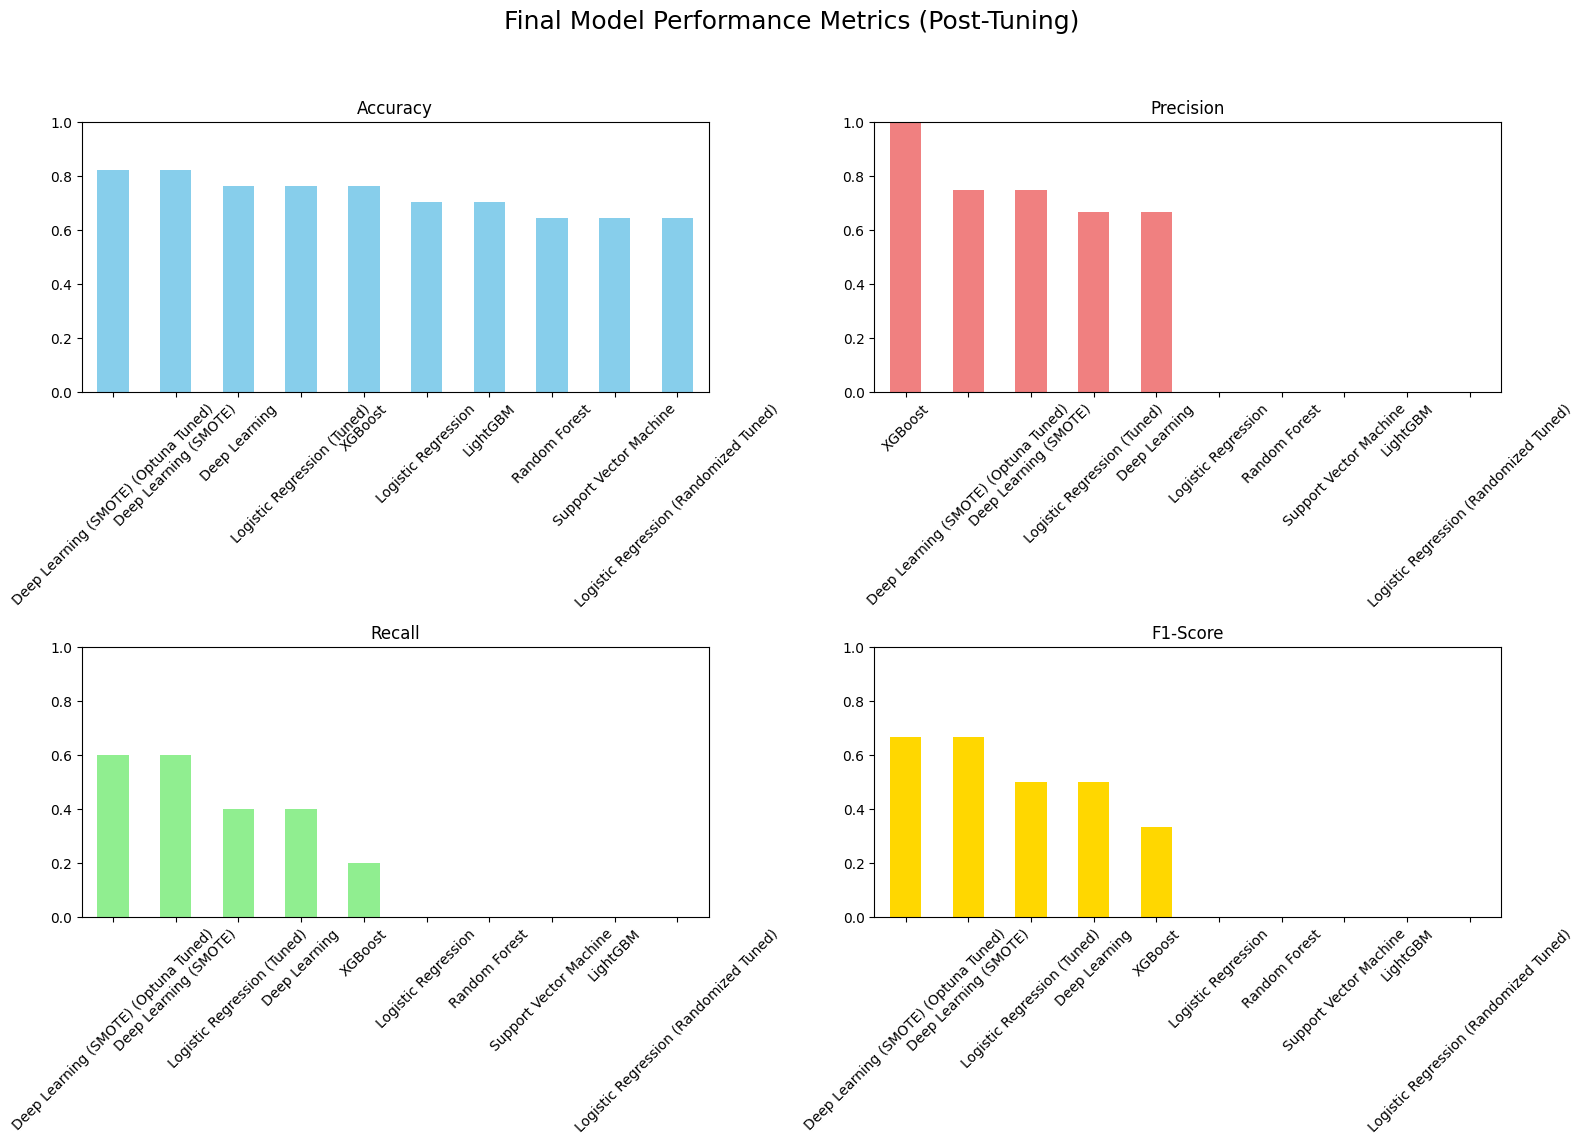

In [ ]:
print("\n--- Final Comprehensive Model Evaluation ---\n")

final_all_metrics = {}

# Include all trained models, including those from GridSearchCV and RandomizedSearchCV
# and the Optuna-tuned Deep Learning model.
# The `trained_models` dictionary should already contain the tuned Logistic Regression models.

# Create a comprehensive dictionary for evaluation
final_evaluated_models = {
    **trained_models, # Includes LR, RF, SVM, XGB, LGBM, LR (Tuned), LR (Randomized Tuned)
    'Deep Learning': model, # Original DL model
    'Deep Learning (SMOTE)': smote_model, # SMOTE DL model
    'Deep Learning (SMOTE) (Optuna Tuned)': optuna_smote_model # Optuna Tuned DL model
}

for name, current_model in final_evaluated_models.items():
    print(f"Evaluating {name}...")

    if name in ['Deep Learning', 'Deep Learning (SMOTE)', 'Deep Learning (SMOTE) (Optuna Tuned)']:
        # Deep Learning models expect dense arrays
        y_pred_proba = current_model.predict(X_test_dense)
        y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions
    else:
        # Traditional models expect sparse matrices
        # Need to make sure `X_test` is the sparse matrix and `X_test_dense` is the dense array.
        # Logistic Regression (Tuned) and Randomized Tuned will also use sparse `X_test`
        y_pred = current_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0) # zero_division=0 to handle cases with no positive predictions
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    final_all_metrics[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}\n")

print("\n--- Detailed Metrics Summary (DataFrame) ---\n")
final_metrics_df = pd.DataFrame(final_all_metrics).T # Transpose to have models as rows
print(final_metrics_df.round(4))

# Visualize metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Final Model Performance Metrics (Post-Tuning)', fontsize=18)

final_metrics_df['Accuracy'].sort_values(ascending=False).plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Accuracy')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].tick_params(axis='x', rotation=45)

final_metrics_df['Precision'].sort_values(ascending=False).plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Precision')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis='x', rotation=45)

final_metrics_df['Recall'].sort_values(ascending=False).plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Recall')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=45)

final_metrics_df['F1-Score'].sort_values(ascending=False).plot(kind='bar', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('F1-Score')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


--- Final Confusion Matrix Analysis for Deep Learning (SMOTE) (Optuna Tuned) ---

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


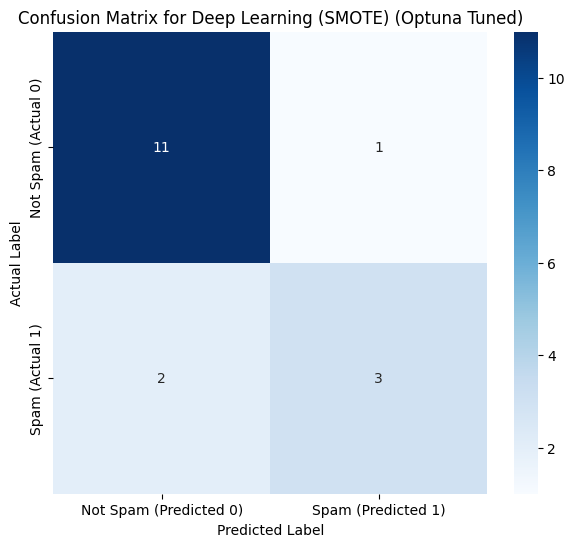

True Positives (TP): 3 (Correctly predicted Spam)
True Negatives (TN): 11 (Correctly predicted Not Spam)
False Positives (FP): 1 (Incorrectly predicted Spam - Type I error)
False Negatives (FN): 2 (Incorrectly predicted Not Spam - Type II error)

**Explanation of False Positives (FP) and False Negatives (FN):**

**False Positives (FP):** These occur when the model incorrectly predicts a positive class (e.g., 'Spam') when the actual class is negative (e.g., 'Not Spam'). In a spam detection context, this means a legitimate email was mistakenly flagged as spam. The consequence is that the user might miss important communications, which can be very frustrating. Clients care about minimizing these if the cost of missing a legitimate email is high.

**False Negatives (FN):** These occur when the model incorrectly predicts a negative class (e.g., 'Not Spam') when the actual class is positive (e.g., 'Spam'). In spam detection, this means a spam email slipped through the filter and landed in th

In [ ]:
print("\n--- Final Confusion Matrix Analysis for Deep Learning (SMOTE) (Optuna Tuned) ---\n")

# Get predictions for the Optuna-tuned Deep Learning (SMOTE) model
# X_test_dense is already available from previous steps
y_pred_proba_optuna = optuna_smote_model.predict(X_test_dense)
y_pred_optuna = (y_pred_proba_optuna > 0.5).astype(int) # Convert probabilities to binary predictions

# Calculate the confusion matrix
cm_optuna = confusion_matrix(y_test, y_pred_optuna)

# Visualize the confusion matrix
plt.figure(figsize=(7, 6))
sns.heatmap(cm_optuna, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam (Predicted 0)', 'Spam (Predicted 1)'],
            yticklabels=['Not Spam (Actual 0)', 'Spam (Actual 1)'])
plt.title('Confusion Matrix for Deep Learning (SMOTE) (Optuna Tuned)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Extract and explain False Positives and False Negatives
tn, fp, fn, tp = cm_optuna.ravel() # True Negative, False Positive, False Negative, True Positive

print(f"True Positives (TP): {tp} (Correctly predicted Spam)")
print(f"True Negatives (TN): {tn} (Correctly predicted Not Spam)")
print(f"False Positives (FP): {fp} (Incorrectly predicted Spam - Type I error)")
print(f"False Negatives (FN): {fn} (Incorrectly predicted Not Spam - Type II error)\n")

print("**Explanation of False Positives (FP) and False Negatives (FN):**\n")
print("**False Positives (FP):** These occur when the model incorrectly predicts a positive class (e.g., 'Spam') when the actual class is negative (e.g., 'Not Spam'). In a spam detection context, this means a legitimate email was mistakenly flagged as spam. The consequence is that the user might miss important communications, which can be very frustrating. Clients care about minimizing these if the cost of missing a legitimate email is high.")
print("\n**False Negatives (FN):** These occur when the model incorrectly predicts a negative class (e.g., 'Not Spam') when the actual class is positive (e.g., 'Spam'). In spam detection, this means a spam email slipped through the filter and landed in the user's inbox. The consequence is that the user is exposed to unwanted or potentially malicious content. Clients care about minimizing these if the cost of receiving spam (e.g., security risk, wasted time) is high.")
print("\nUnderstanding the balance between these two types of errors is crucial. Depending on the client's priorities, one error might be more costly than the other. For instance, in medical diagnoses, false negatives (missing a disease) are often more critical than false positives (a false alarm).")

In [ ]:
print("\n--- Saving Full Pipeline Components ---\n")

# Create a directory to save the models and components
save_dir = 'trained_pipeline_components'
os.makedirs(save_dir, exist_ok=True)

# 1. Save the best performing model (Deep Learning SMOTE Optuna Tuned)
# The 'optuna_smote_model' is a Keras model.
model_save_path = os.path.join(save_dir, 'best_dl_model_optuna.keras') # Keras native format
optuna_smote_model.save(model_save_path)
print(f"Saved best Deep Learning model to: {model_save_path}")

# 2. Save the TF-IDF Vectorizer
vectorizer_save_path = os.path.join(save_dir, 'tfidf_vectorizer.pkl')
with open(vectorizer_save_path, 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print(f"Saved TF-IDF Vectorizer to: {vectorizer_save_path}")

# 3. Save the Label Encoder
label_encoder_save_path = os.path.join(save_dir, 'label_encoder.pkl')
with open(label_encoder_save_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"Saved Label Encoder to: {label_encoder_save_path}")

print("\nAll specified pipeline components (model, vectorizer, label encoder) have been saved.")
print("Note: The `preprocess_text` function, along with its NLTK dependencies (lemmatizer, stemmer, word_tokenizer, stopwords), is defined within the notebook and should be directly included in your deployment script to ensure consistent text preprocessing.")



--- Saving Full Pipeline Components ---

Saved best Deep Learning model to: trained_pipeline_components/best_dl_model_optuna.keras
Saved TF-IDF Vectorizer to: trained_pipeline_components/tfidf_vectorizer.pkl
Saved Label Encoder to: trained_pipeline_components/label_encoder.pkl

All specified pipeline components (model, vectorizer, label encoder) have been saved.
Note: The `preprocess_text` function, along with its NLTK dependencies (lemmatizer, stemmer, word_tokenizer, stopwords), is defined within the notebook and should be directly included in your deployment script to ensure consistent text preprocessing.
